# Postprocessing method comparison

Compares postprocessing strategies on the **training set** (LOAO CV) for all models.

| Method | Input | Description |
|--------|-------|-------------|
| `none` | hard labels | baseline — no postprocessing |
| `min_duration_filter` | hard labels | absorbs short segments into preceding class |
| `majority_vote_filter` | hard labels | symmetric sliding-window majority |
| `smooth_probs_argmax` | soft probabilities | smooth probs then argmax |
| `viterbi` | soft probabilities | 4-state HMM Viterbi decoding |

**Models**: XGBoost (pose), Image XGBoost, Pose TCN, Image TCN, ResNet — all evaluated via LOAO CV on the training set.

**Metrics**: macro F1, per-class F1, number/percentage of labels changed, gait event false positives/negatives.

In [1]:
import joblib
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from experiments.gait_detection.config import ExperimentConfig
from src.gait.detection.metrics import per_class_f1
from src.gait.detection.postprocess import (
    estimate_hmm_params,
    min_duration_filter,
    majority_vote_filter,
    smooth_probs_argmax,
    viterbi_decode,
)
from src.gait.gait_data.dataset import load_dataset, loao_splits, train_test_split
from src.gait.image.dataset import load_image_dataset

# ── config ────────────────────────────────────────────────────────────────────
TCN_MANIFEST         = "data/output/gait/pose_data/stage6/manifest.json"
IMG_TCN_MANIFEST     = "data/output/gait/image/stage6/manifest.json"
RESNET_MANIFEST      = "data/output/gait/image/resnet/infer/manifest.json"

XGB_LOAO_MANIFEST     = "data/output/gait/pose_data/xgb_loao/manifest.json"
IMG_XGB_LOAO_MANIFEST = "data/output/gait/image/xgb_loao/manifest.json"
TCN_LOAO_MANIFEST     = "data/output/gait/pose_data/stage4/manifest.json"
IMG_TCN_LOAO_MANIFEST = "data/output/gait/image/stage4/manifest.json"
RESNET_LOAO_MANIFEST  = "data/output/gait/image/resnet/loao/manifest.json"

IMG_XGB_MODEL_PATH = "data/output/gait/image/stage1/checkpoints/xgboost_best.pkl"

IMG_FEATURES_DIR = "data/output/gait/image_features"
VIDEO_INPUT_DIR  = "data/input/optojump"

WINDOWS = [3, 5, 7, 9, 11]

In [2]:
import os, pathlib
_cwd = pathlib.Path.cwd()
if not (_cwd / "configs" / "dataset.yaml").exists():
    os.chdir(_cwd.parent)

In [3]:
cfg = ExperimentConfig()
all_records = load_dataset(cfg.annotations_csv, fps=cfg.fps)
train_records, test_records, test_athletes = train_test_split(all_records)

n_athletes = len({r.athlete for r in train_records})
print(f"Train : {len(train_records)} records  ({n_athletes} athletes)")
print(f"Test  : {len(test_records)} records   (excluded: {test_athletes})")

# Image records have a different label clipping window (from frame 0) compared
# to pose records (from first YOLO-detected frame), so load them separately.
img_records_by_path = {}
if os.path.exists(IMG_FEATURES_DIR):
    img_all = load_image_dataset(cfg.annotations_csv, IMG_FEATURES_DIR, VIDEO_INPUT_DIR)
    img_records_by_path = {r.video_path: r for r in img_all}
    print(f"Image : {len(img_all)} records loaded")
else:
    print(f"Image features not found ({IMG_FEATURES_DIR}) — image TCN evaluation will be skipped.")

Train : 162 records  (20 athletes)
Test  : 16 records   (excluded: ['antoni_pejtler', 'milosz_jarzab'])
Image : 178 records loaded


## Helper functions

In [4]:
def apply_postprocessing(
    method: str,
    data: np.ndarray,
    window: int,
    hmm_params: dict | None = None,
) -> np.ndarray:
    """Dispatch to the right postprocessing function.

    `data` is a 1-D label array for hard-label methods,
    or a (T, n_classes) probability array for prob-based methods.
    `hmm_params` must be provided when method == "viterbi".
    """
    if method == "none":
        return data
    if method == "min_duration_filter":
        return min_duration_filter(data, min_frames=window)
    if method == "majority_vote_filter":
        return majority_vote_filter(data, window=window)
    if method == "smooth_probs_argmax":
        return smooth_probs_argmax(data, window=window)
    if method == "viterbi":
        return viterbi_decode(data, **hmm_params)
    raise ValueError(f"Unknown postprocessing method: {method!r}")


PROB_METHODS = frozenset({"smooth_probs_argmax", "viterbi"})

# Methods that have no window parameter (single evaluation point)
WINDOWLESS_METHODS = frozenset({"none", "viterbi"})

# All (method, window) combinations; windowless methods use window=0
METHODS_CONFIG = (
    [("none",    0)] +
    [("viterbi", 0)] +
    [("min_duration_filter",  w) for w in WINDOWS] +
    [("majority_vote_filter", w) for w in WINDOWS] +
    [("smooth_probs_argmax",  w) for w in WINDOWS]
)


def eval_fold_metrics(val_records, preds, raw_labels, n_classes, class_names):
    """Compute F1 and label-change count for one fold."""
    all_true, all_pred = [], []
    n_changed = 0
    n_total = 0

    for rec, pred, raw in zip(val_records, preds, raw_labels):
        all_true.append(rec.labels)
        all_pred.append(pred)
        n_changed += int(np.sum(pred != raw))
        n_total += len(pred)

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    return {
        "f1":        per_class_f1(y_true, y_pred, n_classes, class_names),
        "n_changed": n_changed,
        "n_total":   n_total,
    }

In [5]:
STATE_NAMES = ["S_L", "F_L→R", "S_R", "F_R→L"]

startprob, transmat = estimate_hmm_params([r.labels for r in train_records])
HMM_PARAMS = {"transmat": transmat, "startprob": startprob}

print("HMM startprob:")
print(pd.Series(np.round(startprob, 4), index=STATE_NAMES).to_string())
print("\nHMM transmat (4-state):")
print(pd.DataFrame(np.round(transmat, 4), index=STATE_NAMES, columns=STATE_NAMES).to_string())

HMM startprob:
S_L      0.0185
F_L→R    0.4815
S_R      0.0185
F_R→L    0.4815

HMM transmat (4-state):
          S_L   F_L→R     S_R   F_R→L
S_L    0.9413  0.0587  0.0000  0.0000
F_L→R  0.0000  0.9394  0.0606  0.0000
S_R    0.0000  0.0000  0.9413  0.0587
F_R→L  0.0606  0.0000  0.0000  0.9394


---
## XGBoost — LOAO CV

For each fold: train on N-1 athletes, run `predict_proba` on the held-out athlete.  
Then apply every (method, window) combination and compute metrics.

In [6]:
_select = lambda features, idx: features if idx is None else features[:, idx]

xgb_fold_data = None
XGB_PARAMS = None
feature_idx = None

if not os.path.exists(XGB_LOAO_MANIFEST):
    print(f"XGB LOAO manifest not found ({XGB_LOAO_MANIFEST}).\nRun pose_xgb_loao stage to enable comparison.")
else:
    with open(XGB_LOAO_MANIFEST) as f:
        xgb_loao_manifest = json.load(f)

    XGB_PARAMS  = xgb_loao_manifest["best_params"]
    feature_idx = xgb_loao_manifest.get("feature_idx")

    xgb_manifest_idx = {r["video_path"]: r for r in xgb_loao_manifest["records"]}

    xgb_fold_data = []
    for fold_train, fold_val, athlete in loao_splits(train_records):
        fold_val_m = [r for r in fold_val if r.video_path in xgb_manifest_idx]
        probs      = [np.load(xgb_manifest_idx[r.video_path]["probs_path"]) for r in fold_val_m]
        raw_labels = [p.argmax(axis=1).astype(np.int64) for p in probs]
        xgb_fold_data.append({
            "athlete":     athlete,
            "val_records": fold_val_m,
            "raw_labels":  raw_labels,
            "probs":       probs,
        })
    print(f"XGBoost LOAO manifest loaded  ({len(xgb_loao_manifest['records'])} records, {len(xgb_fold_data)} folds)")


XGBoost LOAO manifest loaded  (162 records, 20 folds)


In [7]:
xgb_results = {}  # (method, window) -> list[fold_result]

if xgb_fold_data is None:
    print("XGBoost LOAO not available — skipping.")
else:
    for method, window in METHODS_CONFIG:
        needs_probs = method in PROB_METHODS
        fold_results = []

        for fold in xgb_fold_data:
            preds = [
                apply_postprocessing(
                    method,
                    fold["probs"][i] if needs_probs else fold["raw_labels"][i],
                    window,
                    hmm_params=HMM_PARAMS,
                )
                for i in range(len(fold["val_records"]))
            ]
            result = eval_fold_metrics(
                fold["val_records"], preds, fold["raw_labels"],
                cfg.n_classes, cfg.class_names,
            )
            result["athlete"] = fold["athlete"]
            fold_results.append(result)

        xgb_results[(method, window)] = fold_results

    print(f"Computed {len(xgb_results)} (method, window) combinations for XGBoost.")


Computed 17 (method, window) combinations for XGBoost.


---
## Image XGBoost — LOAO CV

Loads per-fold softmax probabilities from the `img_xgb_loao` stage manifest.
Also loads the full trained model for test-set evaluation.


In [8]:
img_xgb_results = None
img_xgb_clf = None

if not os.path.exists(IMG_XGB_LOAO_MANIFEST):
    print(f"Image XGBoost LOAO manifest not found ({IMG_XGB_LOAO_MANIFEST}).\nRun img_xgb_loao stage to enable comparison.")
elif not img_records_by_path:
    print("Image records not loaded — skipping image XGBoost evaluation.")
else:
    with open(IMG_XGB_LOAO_MANIFEST) as f:
        img_xgb_loao_manifest = json.load(f)

    img_xgb_manifest_idx = {r["video_path"]: r for r in img_xgb_loao_manifest["records"]}

    img_xgb_fold_data = []
    img_train_recs_all = [img_records_by_path[r.video_path]
                          for r in train_records if r.video_path in img_records_by_path]
    img_train_recs_set = {r.video_path for r in img_train_recs_all}

    for fold_train, fold_val, athlete in loao_splits(train_records):
        fold_val_m = [
            img_records_by_path[r.video_path]
            for r in fold_val
            if r.video_path in img_records_by_path and r.video_path in img_xgb_manifest_idx
        ]
        probs      = [np.load(img_xgb_manifest_idx[r.video_path]["probs_path"]) for r in fold_val_m]
        raw_labels = [p.argmax(axis=1).astype(np.int64) for p in probs]
        img_xgb_fold_data.append({
            "athlete":     athlete,
            "val_records": fold_val_m,
            "raw_labels":  raw_labels,
            "probs":       probs,
        })

    print(f"Image XGBoost LOAO manifest loaded  ({len(img_xgb_loao_manifest['records'])} records, {len(img_xgb_fold_data)} folds)")

    img_xgb_results = {}
    for method, window in METHODS_CONFIG:
        needs_probs = method in PROB_METHODS
        fold_results = []
        for fold in img_xgb_fold_data:
            preds = [
                apply_postprocessing(
                    method,
                    fold["probs"][i] if needs_probs else fold["raw_labels"][i],
                    window,
                    hmm_params=HMM_PARAMS,
                )
                for i in range(len(fold["val_records"]))
            ]
            result = eval_fold_metrics(
                fold["val_records"], preds, fold["raw_labels"],
                cfg.n_classes, cfg.class_names,
            )
            result["athlete"] = fold["athlete"]
            fold_results.append(result)
        img_xgb_results[(method, window)] = fold_results

    print(f"Computed {len(img_xgb_results)} (method, window) combinations for Image XGBoost.")

    # Load full model for test-set evaluation
    if os.path.exists(IMG_XGB_MODEL_PATH):
        img_xgb_clf = joblib.load(IMG_XGB_MODEL_PATH)
        print(f"Loaded image XGBoost model for test evaluation: {IMG_XGB_MODEL_PATH}")


Image XGBoost LOAO manifest loaded  (162 records, 20 folds)
Computed 17 (method, window) combinations for Image XGBoost.
Loaded image XGBoost model for test evaluation: data/output/gait/image/stage1/checkpoints/xgboost_best.pkl


---
## Pose TCN — LOAO CV

Loads raw softmax probabilities from the LOAO manifest (held-out per-athlete predictions).

In [9]:
tcn_results = None

if not os.path.exists(TCN_LOAO_MANIFEST):
    print(f"TCN LOAO manifest not found ({TCN_LOAO_MANIFEST}).\nRun the pose TCN LOAO stage to enable comparison.")
else:
    with open(TCN_LOAO_MANIFEST) as f:
        tcn_loao_manifest = json.load(f)

    tcn_loao_idx = {r["video_path"]: r for r in tcn_loao_manifest["records"]}

    tcn_fold_data = []
    for fold_train, fold_val, athlete in loao_splits(train_records):
        fold_val_m = [r for r in fold_val if r.video_path in tcn_loao_idx]
        probs      = [np.load(tcn_loao_idx[r.video_path]["probs_path"]) for r in fold_val_m]
        raw_labels = [p.argmax(axis=1).astype(np.int64) for p in probs]
        tcn_fold_data.append({
            "athlete":     athlete,
            "val_records": fold_val_m,
            "raw_labels":  raw_labels,
            "probs":       probs,
        })

    print(f"Pose TCN LOAO manifest loaded  ({len(tcn_loao_manifest['records'])} records, {len(tcn_fold_data)} folds)")

    tcn_results = {}
    for method, window in METHODS_CONFIG:
        needs_probs = method in PROB_METHODS
        fold_results = []
        for fold in tcn_fold_data:
            preds = [
                apply_postprocessing(
                    method,
                    fold["probs"][i] if needs_probs else fold["raw_labels"][i],
                    window,
                    hmm_params=HMM_PARAMS,
                )
                for i in range(len(fold["val_records"]))
            ]
            result = eval_fold_metrics(
                fold["val_records"], preds, fold["raw_labels"],
                cfg.n_classes, cfg.class_names,
            )
            result["athlete"] = fold["athlete"]
            fold_results.append(result)
        tcn_results[(method, window)] = fold_results

    print(f"Computed {len(tcn_results)} (method, window) combinations for Pose TCN.")

Pose TCN LOAO manifest loaded  (162 records, 20 folds)
Computed 17 (method, window) combinations for Pose TCN.


---
## Image TCN — LOAO CV

Loads raw softmax probabilities from the image TCN LOAO manifest (held-out per-athlete predictions).
Image records are used so that labels align with the image frame count.

In [10]:
img_tcn_results = None

if not os.path.exists(IMG_TCN_LOAO_MANIFEST):
    print(f"Image TCN LOAO manifest not found ({IMG_TCN_LOAO_MANIFEST}).\nRun img_tcn_loao stage to enable comparison.")
elif not img_records_by_path:
    print("Image records not loaded — skipping Image TCN evaluation.")
else:
    with open(IMG_TCN_LOAO_MANIFEST) as f:
        img_tcn_loao_manifest = json.load(f)

    img_tcn_loao_idx = {r["video_path"]: r for r in img_tcn_loao_manifest["records"]}

    img_tcn_fold_data = []
    for fold_train, fold_val, athlete in loao_splits(train_records):
        fold_val_m = [
            img_records_by_path[r.video_path]
            for r in fold_val
            if r.video_path in img_records_by_path and r.video_path in img_tcn_loao_idx
        ]
        probs      = [np.load(img_tcn_loao_idx[r.video_path]["probs_path"]) for r in fold_val_m]
        raw_labels = [p.argmax(axis=1).astype(np.int64) for p in probs]
        img_tcn_fold_data.append({
            "athlete":     athlete,
            "val_records": fold_val_m,
            "raw_labels":  raw_labels,
            "probs":       probs,
        })

    print(f"Image TCN LOAO manifest loaded  ({len(img_tcn_loao_manifest['records'])} records, {len(img_tcn_fold_data)} folds)")

    img_tcn_results = {}
    for method, window in METHODS_CONFIG:
        needs_probs = method in PROB_METHODS
        fold_results = []
        for fold in img_tcn_fold_data:
            preds = [
                apply_postprocessing(
                    method,
                    fold["probs"][i] if needs_probs else fold["raw_labels"][i],
                    window,
                    hmm_params=HMM_PARAMS,
                )
                for i in range(len(fold["val_records"]))
            ]
            result = eval_fold_metrics(
                fold["val_records"], preds, fold["raw_labels"],
                cfg.n_classes, cfg.class_names,
            )
            result["athlete"] = fold["athlete"]
            fold_results.append(result)
        img_tcn_results[(method, window)] = fold_results

    print(f"Computed {len(img_tcn_results)} (method, window) combinations for Image TCN.")

Image TCN LOAO manifest loaded  (162 records, 20 folds)
Computed 17 (method, window) combinations for Image TCN.


---
## ResNet linear head — LOAO CV

Loads per-fold softmax probabilities from the `img_resnet_loao` stage manifest.
Inference-manifest probs (full model) are used for test-set evaluation.


In [11]:
resnet_results = None

# resnet_manifest_idx keeps the inference-manifest index (train+test) for test-set eval
resnet_manifest_idx = {}
if os.path.exists(RESNET_MANIFEST):
    with open(RESNET_MANIFEST) as f:
        _resnet_infer_manifest = json.load(f)
    resnet_manifest_idx = {r["video_path"]: r for r in _resnet_infer_manifest["records"]}

if not os.path.exists(RESNET_LOAO_MANIFEST):
    print(f"ResNet LOAO manifest not found ({RESNET_LOAO_MANIFEST}).\nRun img_resnet_loao stage to enable comparison.")
elif not img_records_by_path:
    print("Image records not loaded — skipping ResNet evaluation.")
else:
    with open(RESNET_LOAO_MANIFEST) as f:
        resnet_loao_manifest = json.load(f)

    resnet_loao_idx = {r["video_path"]: r for r in resnet_loao_manifest["records"]}

    resnet_fold_data = []
    for fold_train, fold_val, athlete in loao_splits(train_records):
        fold_val_m = [
            img_records_by_path[r.video_path]
            for r in fold_val
            if r.video_path in img_records_by_path and r.video_path in resnet_loao_idx
        ]
        probs      = [np.load(resnet_loao_idx[r.video_path]["probs_path"]) for r in fold_val_m]
        raw_labels = [p.argmax(axis=1).astype(np.int64) for p in probs]
        resnet_fold_data.append({
            "athlete":     athlete,
            "val_records": fold_val_m,
            "raw_labels":  raw_labels,
            "probs":       probs,
        })

    print(f"ResNet LOAO manifest loaded  ({len(resnet_loao_manifest['records'])} records, {len(resnet_fold_data)} folds)")

    resnet_results = {}
    for method, window in METHODS_CONFIG:
        needs_probs = method in PROB_METHODS
        fold_results = []
        for fold in resnet_fold_data:
            preds = [
                apply_postprocessing(
                    method,
                    fold["probs"][i] if needs_probs else fold["raw_labels"][i],
                    window,
                    hmm_params=HMM_PARAMS,
                )
                for i in range(len(fold["val_records"]))
            ]
            result = eval_fold_metrics(
                fold["val_records"], preds, fold["raw_labels"],
                cfg.n_classes, cfg.class_names,
            )
            result["athlete"] = fold["athlete"]
            fold_results.append(result)
        resnet_results[(method, window)] = fold_results

    print(f"Computed {len(resnet_results)} (method, window) combinations for ResNet linear head.")


ResNet LOAO manifest loaded  (162 records, 20 folds)
Computed 17 (method, window) combinations for ResNet linear head.


---
## Build summary table

In [12]:
def build_summary(results_dict: dict, model_label: str) -> pd.DataFrame:
    rows = []
    for (method, window), folds in results_dict.items():
        macro_f1s = [f["f1"]["macro"] for f in folds]
        n_changed = sum(f["n_changed"] for f in folds)
        n_total   = sum(f["n_total"]   for f in folds)

        row = {
            "model":       model_label,
            "method":      method,
            "window":      window,
            "macro_f1":    float(np.mean(macro_f1s)),
            "n_changed":   n_changed,
            "pct_changed": 100.0 * n_changed / n_total if n_total > 0 else 0.0,
        }
        for cls in [k for k in folds[0]["f1"] if k != "macro"]:
            row[f"f1_{cls}"] = float(np.mean([f["f1"].get(cls, np.nan) for f in folds]))
        rows.append(row)
    return pd.DataFrame(rows)


dfs = [build_summary(xgb_results, "XGBoost")]
if img_xgb_results is not None:
    dfs.append(build_summary(img_xgb_results, "Image XGBoost"))
if tcn_results is not None:
    dfs.append(build_summary(tcn_results, "Pose TCN"))
if img_tcn_results is not None:
    dfs.append(build_summary(img_tcn_results, "Image TCN"))
if resnet_results is not None:
    dfs.append(build_summary(resnet_results, "ResNet linear head"))

summary = pd.concat(dfs, ignore_index=True)
summary["method_short"] = summary["method"].str.replace("_filter", "").str.replace("_argmax", "")

# delta_f1: improvement over the no-postprocessing baseline (positive = better)
baseline_f1 = (
    summary[summary["method"] == "none"]
    .set_index("model")["macro_f1"]
    .rename("_baseline_f1")
)
summary = summary.join(baseline_f1, on="model")
summary["delta_f1"] = summary["macro_f1"] - summary["_baseline_f1"]
summary = summary.drop(columns=["_baseline_f1"])

print(summary.to_string(index=False))

             model               method  window  macro_f1  n_changed  pct_changed  f1_left_stance  f1_right_stance  f1_flight  method_short  delta_f1
           XGBoost                 none       0  0.852255          0     0.000000        0.842291         0.851383   0.863090          none  0.000000
           XGBoost              viterbi       0  0.862078        334     1.900319        0.855233         0.863199   0.867800       viterbi  0.009823
           XGBoost  min_duration_filter       3  0.853332        209     1.189122        0.845361         0.852586   0.862048  min_duration  0.001077
           XGBoost  min_duration_filter       5  0.843904        692     3.937187        0.838745         0.845595   0.847373  min_duration -0.008351
           XGBoost  min_duration_filter       7  0.840330       1091     6.207328        0.833774         0.846345   0.840869  min_duration -0.011925
           XGBoost  min_duration_filter       9  0.816481       1748     9.945380        0.812171   

In [13]:
summary[summary['method_short'] == 'viterbi']

,model,method,window,macro_f1,n_changed,pct_changed,f1_left_stance,f1_right_stance,f1_flight,method_short,delta_f1
1,XGBoost,viterbi,0,0.862078,334,1.900319,0.855233,0.863199,0.867800,viterbi,0.009823
18,Image XGBoost,viterbi,0,0.778004,1748,8.367640,0.736971,0.773818,0.823222,viterbi,0.060102
35,Pose TCN,viterbi,0,0.858063,238,1.354119,0.857252,0.860808,0.856130,viterbi,0.005264
52,Image TCN,viterbi,0,0.837563,457,2.187650,0.836243,0.828658,0.847790,viterbi,0.005563
69,ResNet linear head,viterbi,0,0.829852,611,2.924844,0.818419,0.809963,0.861175,viterbi,0.020651


---
## Visualisation

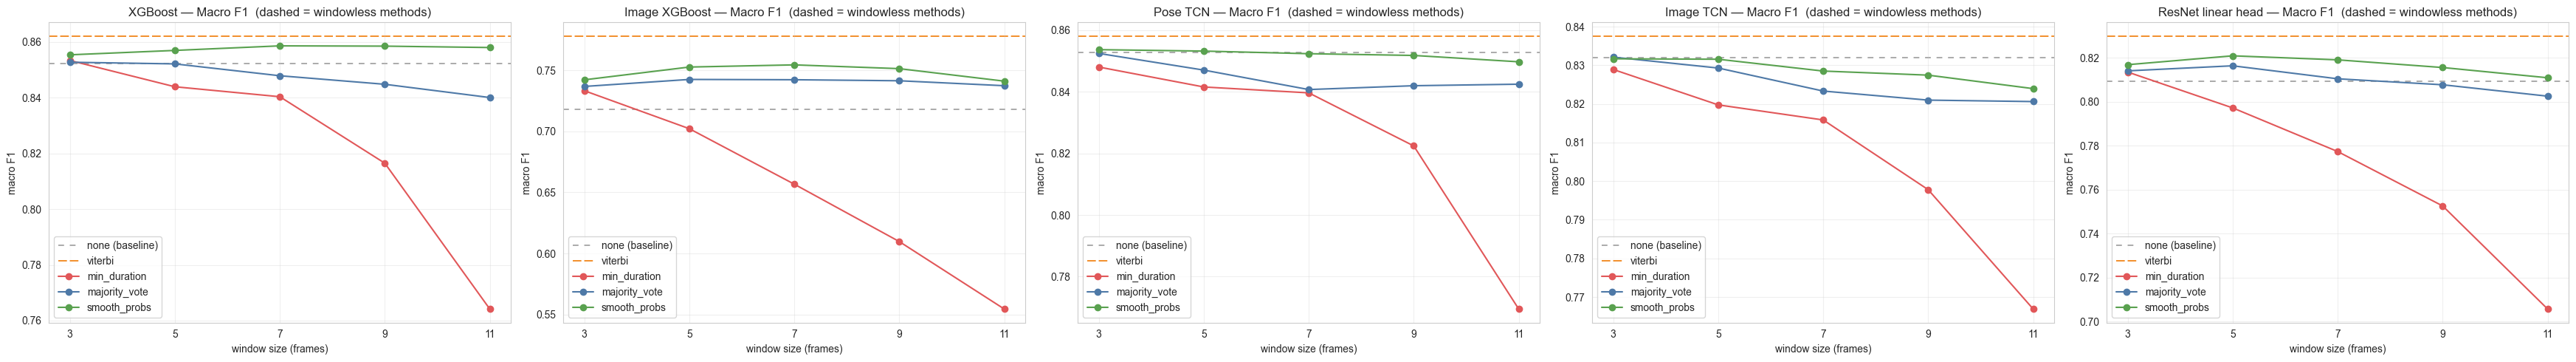

In [14]:
METHOD_COLORS = {
    "none":                 "#aaaaaa",
    "viterbi":              "#f28e2b",
    "min_duration_filter":  "#e15759",
    "majority_vote_filter": "#4e79a7",
    "smooth_probs_argmax":  "#59a14f",
}
METHOD_LABELS = {
    "none":                 "none (baseline)",
    "viterbi":              "viterbi",
    "min_duration_filter":  "min_duration",
    "majority_vote_filter": "majority_vote",
    "smooth_probs_argmax":  "smooth_probs",
}
LINE_STYLES = {
    "none":    (0, (4, 4)),   # dashed, gray
    "viterbi": (0, (6, 2)),   # long-dash, orange
}


def _plot_f1_lines(df, models, metric, ylabel, title):
    n_models = len(models)
    fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 5))
    if n_models == 1:
        axes = [axes]

    for ax, model in zip(axes, models):
        sub = df[df["model"] == model].copy()
        for method, grp in sub.groupby("method", sort=False):
            color = METHOD_COLORS[method]
            label = METHOD_LABELS[method]
            if method in WINDOWLESS_METHODS:
                val = grp[metric].iloc[0]
                ax.axhline(val, color=color, linestyle=LINE_STYLES[method],
                           linewidth=1.4, label=label, zorder=0)
            else:
                grp = grp.sort_values("window")
                ax.plot(grp["window"], grp[metric], marker="o",
                        color=color, label=label)
        ax.set_xlabel("window size (frames)")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{model} — {title}")
        ax.set_xticks(WINDOWS)
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


models_present = summary["model"].unique().tolist()

_plot_f1_lines(summary, models_present, "macro_f1",
               ylabel="macro F1",
               title="Macro F1  (dashed = windowless methods)")

In [15]:
def plot_labels_changed(model_label):
    # Windowless methods have no meaningful x-axis, so exclude them from the line plot
    sub = summary[
        (summary["model"] == model_label) &
        (~summary["method"].isin(WINDOWLESS_METHODS))
    ].copy()

    fig, ax = plt.subplots(figsize=(8, 4))
    for method, grp in sub.groupby("method", sort=False):
        grp = grp.sort_values("window")
        ax.plot(grp["window"], grp["pct_changed"], marker="o",
                color=METHOD_COLORS[method], label=METHOD_LABELS[method])

    # Add windowless methods as horizontal reference lines
    wl = summary[(summary["model"] == model_label) & (summary["method"].isin(WINDOWLESS_METHODS))]
    for _, row in wl.iterrows():
        ax.axhline(row["pct_changed"], color=METHOD_COLORS[row["method"]],
                   linestyle=LINE_STYLES[row["method"]], linewidth=1.4,
                   label=METHOD_LABELS[row["method"]])

    ax.set_xlabel("window size (frames)")
    ax.set_ylabel("labels changed (%)")
    ax.set_title(f"{model_label} — % of labels changed by postprocessing")
    ax.set_xticks(WINDOWS)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# for m in models_present:
#     plot_labels_changed(m)

# Summary table
# display(
#     summary[["model", "method", "window", "n_changed", "pct_changed", "macro_f1", "delta_f1"]]
#     .sort_values(["model", "method", "window"])
#     .reset_index(drop=True)
#     .style.format({"pct_changed": "{:.2f}%", "macro_f1": "{:.4f}", "delta_f1": "{:+.4f}"})
# )

---
## Best configuration per model

Rank postprocessed configurations by macro F1 (descending).
The no-postprocessing baseline (`none`) is shown first for reference.

In [16]:
f1_cols = [c for c in summary.columns if c.startswith("f1_")]

# No-postprocessing baseline
baseline = (
    summary[summary["method"] == "none"]
    .groupby("model", sort=False)[["macro_f1"] + f1_cols]
    .mean()
    .reset_index()
    .rename(columns={"macro_f1": "baseline_macro_f1"})
)
print("Baseline (no postprocessing):")
display(baseline)

# Best postprocessed config per model (highest macro F1)
best = (
    summary[summary["method"] != "none"]
    .sort_values("macro_f1", ascending=False)
    .groupby("model", sort=False)
    .first()
    [["method", "window", "macro_f1", "pct_changed"] + f1_cols]
    .reset_index()
)
print("\nBest postprocessed config per model:")
display(best)

Baseline (no postprocessing):


,model,baseline_macro_f1,f1_left_stance,f1_right_stance,f1_flight
0,XGBoost,0.852255,0.842291,0.851383,0.863090
1,Image XGBoost,0.717902,0.641061,0.695887,0.816760
2,Pose TCN,0.852800,0.849294,0.856439,0.852666
3,Image TCN,0.832000,0.829742,0.820229,0.846030
4,ResNet linear head,0.809200,0.784834,0.782981,0.859787



Best postprocessed config per model:


,model,method,window,macro_f1,pct_changed,f1_left_stance,f1_right_stance,f1_flight
0,XGBoost,viterbi,0,0.862078,1.900319,0.855233,0.863199,0.867800
1,Pose TCN,viterbi,0,0.858063,1.354119,0.857252,0.860808,0.856130
2,Image TCN,viterbi,0,0.837563,2.187650,0.836243,0.828658,0.847790
3,ResNet linear head,viterbi,0,0.829852,2.924844,0.818419,0.809963,0.861175
4,Image XGBoost,viterbi,0,0.778004,8.367640,0.736971,0.773818,0.823222


---
## Test set evaluation

For each model: apply **no postprocessing** (baseline), **Viterbi**, and the **best windowed method**
selected on the training set (best macro F1 among `min_duration_filter`, `majority_vote_filter`,
`smooth_probs_argmax` across all window sizes).

XGBoost is retrained on all train athletes before predicting on the held-out test athletes.
All other models load their saved test-split probabilities from the inference manifests.

In [17]:
test_model_data = {}  # model_label -> {val_records, raw_labels, probs}

# ── XGBoost: retrain on full train set, predict on test ───────────────────────
X_tr_all = np.vstack([_select(r.features, feature_idx) for r in train_records])
y_tr_all  = np.concatenate([r.labels for r in train_records])
clf_full  = xgb.XGBClassifier(
    **XGB_PARAMS,
    eval_metric="mlogloss", tree_method="hist", device="cpu", verbosity=0,
)
clf_full.fit(X_tr_all, y_tr_all)
xgb_test_probs  = [clf_full.predict_proba(_select(r.features, feature_idx)) for r in test_records]
xgb_test_labels = [p.argmax(axis=1).astype(np.int64) for p in xgb_test_probs]
test_model_data["XGBoost"] = {
    "val_records": test_records, "raw_labels": xgb_test_labels, "probs": xgb_test_probs,
}
print(f"XGBoost:      {len(test_records)} test records  (retrained on all {len(train_records)} train records)")

# ── Image XGBoost ─────────────────────────────────────────────────────────────
if img_xgb_results is not None and img_xgb_clf is not None:
    img_xgb_test_recs = [
        img_records_by_path[r.video_path]
        for r in test_records if r.video_path in img_records_by_path
    ]
    img_xgb_test_probs  = [img_xgb_clf.predict_proba(r.features) for r in img_xgb_test_recs]
    img_xgb_test_labels = [p.argmax(axis=1).astype(np.int64) for p in img_xgb_test_probs]
    test_model_data["Image XGBoost"] = {
        "val_records": img_xgb_test_recs, "raw_labels": img_xgb_test_labels, "probs": img_xgb_test_probs,
    }
    print(f"Image XGBoost: {len(img_xgb_test_recs)} test records")

# ── Pose TCN ──────────────────────────────────────────────────────────────────
if os.path.exists(TCN_MANIFEST):
    with open(TCN_MANIFEST) as f:
        _tcn_infer = json.load(f)
    _tcn_infer_idx = {r["video_path"]: r for r in _tcn_infer["records"]}
    tcn_test_recs = [
        r for r in test_records
        if r.video_path in _tcn_infer_idx and _tcn_infer_idx[r.video_path]["split"] == "test"
    ]
    if tcn_test_recs:
        tcn_test_probs  = [np.load(_tcn_infer_idx[r.video_path]["probs_path"]) for r in tcn_test_recs]
        tcn_test_labels = [p.argmax(axis=1).astype(np.int64) for p in tcn_test_probs]
        test_model_data["Pose TCN"] = {
            "val_records": tcn_test_recs, "raw_labels": tcn_test_labels, "probs": tcn_test_probs,
        }
        print(f"Pose TCN:     {len(tcn_test_recs)} test records")

# ── Image TCN ─────────────────────────────────────────────────────────────────
if os.path.exists(IMG_TCN_MANIFEST):
    with open(IMG_TCN_MANIFEST) as f:
        _img_tcn_infer = json.load(f)
    _img_tcn_infer_idx = {r["video_path"]: r for r in _img_tcn_infer["records"]}
    img_tcn_test_recs = [
        img_records_by_path[r.video_path]
        for r in test_records
        if r.video_path in _img_tcn_infer_idx
        and _img_tcn_infer_idx[r.video_path]["split"] == "test"
        and r.video_path in img_records_by_path
    ]
    if img_tcn_test_recs:
        img_tcn_test_probs  = [np.load(_img_tcn_infer_idx[r.video_path]["probs_path"]) for r in img_tcn_test_recs]
        img_tcn_test_labels = [p.argmax(axis=1).astype(np.int64) for p in img_tcn_test_probs]
        test_model_data["Image TCN"] = {
            "val_records": img_tcn_test_recs, "raw_labels": img_tcn_test_labels, "probs": img_tcn_test_probs,
        }
        print(f"Image TCN:    {len(img_tcn_test_recs)} test records")

# ── ResNet linear head ────────────────────────────────────────────────────────
if resnet_results is not None:
    resnet_test_recs = [
        img_records_by_path[r.video_path]
        for r in test_records
        if r.video_path in resnet_manifest_idx
        and resnet_manifest_idx[r.video_path]["split"] == "test"
        and r.video_path in img_records_by_path
    ]
    resnet_test_probs  = [np.load(resnet_manifest_idx[r.video_path]["probs_path"]) for r in resnet_test_recs]
    resnet_test_labels = [p.argmax(axis=1).astype(np.int64) for p in resnet_test_probs]
    test_model_data["ResNet linear head"] = {
        "val_records": resnet_test_recs, "raw_labels": resnet_test_labels, "probs": resnet_test_probs,
    }
    print(f"ResNet:       {len(resnet_test_recs)} test records")

XGBoost:      16 test records  (retrained on all 162 train records)
Image XGBoost: 16 test records
Pose TCN:     16 test records
Image TCN:    16 test records
ResNet:       16 test records


In [18]:
# Best windowed method per model, chosen on training set (excludes viterbi / none)
WINDOWED_METHODS = {"min_duration_filter", "majority_vote_filter", "smooth_probs_argmax"}
best_window_train = (
    summary[summary["method"].isin(WINDOWED_METHODS)]
    .sort_values("macro_f1", ascending=False)
    .groupby("model", sort=False)
    .first()
    [["method", "window"]]
)


def _eval_on_test(data, method, window):
    needs_probs = method in PROB_METHODS
    preds = [
        apply_postprocessing(
            method,
            data["probs"][i] if needs_probs else data["raw_labels"][i],
            window,
            hmm_params=HMM_PARAMS,
        )
        for i in range(len(data["val_records"]))
    ]
    return eval_fold_metrics(
        data["val_records"], preds, data["raw_labels"],
        cfg.n_classes, cfg.class_names,
    )


rows = []
for model_label, data in test_model_data.items():
    base_f1 = _eval_on_test(data, "none",    0)["f1"]["macro"]
    vit_f1  = _eval_on_test(data, "viterbi", 0)["f1"]["macro"]

    bw_method = best_window_train.loc[model_label, "method"]
    bw_window = int(best_window_train.loc[model_label, "window"])
    bw_f1     = _eval_on_test(data, bw_method, bw_window)["f1"]["macro"]
    bw_label  = f"{bw_method.replace('_filter','').replace('_argmax','')}  w={bw_window}"

    rows.append({
        "model":             model_label,
        "baseline_f1":       base_f1,
        "viterbi_f1":        vit_f1,
        "viterbi_Δ":         vit_f1  - base_f1,
        "best_window":       bw_label,
        "best_window_f1":    bw_f1,
        "best_window_Δ":     bw_f1   - base_f1,
    })

test_cmp = pd.DataFrame(rows)
display(
    test_cmp.style.format({
        "baseline_f1":    "{:.4f}",
        "viterbi_f1":     "{:.4f}",
        "viterbi_Δ":      "{:+.4f}",
        "best_window_f1": "{:.4f}",
        "best_window_Δ":  "{:+.4f}",
    })
)

,model,baseline_f1,viterbi_f1,viterbi_Δ,best_window,best_window_f1,best_window_Δ
0,XGBoost,0.9109,0.9091,-0.0018,smooth_probs w=7,0.9138,+0.0029
1,Image XGBoost,0.7061,0.7557,+0.0496,smooth_probs w=7,0.7335,+0.0274
2,Pose TCN,0.9153,0.9153,-0.0000,smooth_probs w=3,0.9159,+0.0006
3,Image TCN,0.8311,0.8551,+0.0239,majority_vote w=3,0.8304,-0.0007
4,ResNet linear head,0.8453,0.8709,+0.0256,smooth_probs w=5,0.8623,+0.0170


---
## Event detection errors: false positives and false negatives

Events are derived from label-sequence transitions (flight→stance = landing, stance→flight = takeoff).
A predicted event is matched to a ground-truth event if it falls within **±5 frames** of it (one-to-one, greedy nearest-neighbour).

- **False positive** — predicted event with no matching annotation event (spurious detection)
- **False negative** — annotation event with no matching predicted event (missed detection)

Comparison: raw argmax (no postprocessing) vs Viterbi, evaluated on the LOAO training set.

In [19]:
from src.gait.detection.postprocess import derive_events

EVENT_KEYS     = ["left_landing", "left_takeoff", "right_landing", "right_takeoff"]
TOLERANCE_S    = 5 / cfg.fps  # ±5-frame matching window


def _match_events(pred_times: np.ndarray, true_times: np.ndarray, tol: float):
    """Greedy nearest-neighbour matching. Returns (fp, fn)."""
    pred_matched, true_matched = set(), set()
    for i, pt in enumerate(pred_times):
        if len(true_times) == 0:
            break
        dists  = np.abs(true_times - pt)
        cands  = [j for j in np.where(dists <= tol)[0] if j not in true_matched]
        if cands:
            best = cands[int(np.argmin(dists[np.array(cands)]))]
            pred_matched.add(i)
            true_matched.add(best)
    return len(pred_times) - len(pred_matched), len(true_times) - len(true_matched)


def _event_errors(true_labels, pred_labels, fps, tol):
    """FP + FN per event type for one record."""
    true_ev = derive_events(true_labels, fps)
    pred_ev = derive_events(pred_labels, fps)
    out = {k: dict(zip(("fp", "fn"), _match_events(pred_ev[k], true_ev[k], tol)))
           for k in EVENT_KEYS}
    out["total"] = {
        "fp": sum(out[k]["fp"] for k in EVENT_KEYS),
        "fn": sum(out[k]["fn"] for k in EVENT_KEYS),
    }
    return out


def _aggregate_event_errors(fold_data, use_viterbi: bool) -> dict:
    """Sum FP/FN over all folds and records."""
    totals = {k: {"fp": 0, "fn": 0} for k in EVENT_KEYS + ["total"]}
    for fold in fold_data:
        for i, rec in enumerate(fold["val_records"]):
            pred = (
                viterbi_decode(fold["probs"][i], **HMM_PARAMS)
                if use_viterbi
                else fold["raw_labels"][i]
            )
            for k, v in _event_errors(rec.labels, pred, cfg.fps, TOLERANCE_S).items():
                totals[k]["fp"] += v["fp"]
                totals[k]["fn"] += v["fn"]
    return totals


# ── collect fold datasets for each model ──────────────────────────────────────
_fold_datasets = {}
if xgb_fold_data is not None:
    _fold_datasets["XGBoost"] = xgb_fold_data
if img_xgb_results is not None:
    _fold_datasets["Image XGBoost"] = img_xgb_fold_data
if tcn_results is not None:
    _fold_datasets["Pose TCN"] = tcn_fold_data
if img_tcn_results is not None:
    _fold_datasets["Image TCN"] = img_tcn_fold_data
if resnet_results is not None:
    _fold_datasets["ResNet linear head"] = resnet_fold_data

# ── build table ───────────────────────────────────────────────────────────────
def _pct_change(before, after):
    if before == 0:
        return float("nan")
    return (after - before) / before * 100


rows = []
for model_name, fdata in _fold_datasets.items():
    raw = _aggregate_event_errors(fdata, use_viterbi=False)
    vit = _aggregate_event_errors(fdata, use_viterbi=True)
    for k in EVENT_KEYS + ["total"]:
        fp_b, fp_a = raw[k]["fp"], vit[k]["fp"]
        fn_b, fn_a = raw[k]["fn"], vit[k]["fn"]
        rows.append({
            "Model":       model_name,
            "Event":       k.replace("_", " "),
            "FP (raw)":    fp_b,
            "FP (viterbi)": fp_a,
            "FP Δ%":       _pct_change(fp_b, fp_a),
            "FN (raw)":    fn_b,
            "FN (viterbi)": fn_a,
            "FN Δ%":       _pct_change(fn_b, fn_a),
        })

event_df = pd.DataFrame(rows)

# ── display: separate tables for each model ───────────────────────────────────
for model_name in _fold_datasets:
    sub = event_df[event_df["Model"] == model_name].set_index("Event")
    display(
        sub.style
        .format({
            "FP Δ%": lambda v: f"{v:+.1f}%" if not pd.isna(v) else "—",
            "FN Δ%": lambda v: f"{v:+.1f}%" if not pd.isna(v) else "—",
        })
    )

,Model,FP (raw),FP (viterbi),FP Δ%,FN (raw),FN (viterbi),FN Δ%
Event,,,,,,,
left landing,XGBoost,54,46,-14.8%,29,29,+0.0%
left takeoff,XGBoost,82,48,-41.5%,12,15,+25.0%
right landing,XGBoost,76,31,-59.2%,24,28,+16.7%
right takeoff,XGBoost,82,39,-52.4%,27,31,+14.8%
total,XGBoost,294,164,-44.2%,92,103,+12.0%


,Model,FP (raw),FP (viterbi),FP Δ%,FN (raw),FN (viterbi),FN Δ%
Event,,,,,,,
left landing,Image XGBoost,339,64,-81.1%,84,40,-52.4%
left takeoff,Image XGBoost,389,90,-76.9%,51,36,-29.4%
right landing,Image XGBoost,289,49,-83.0%,81,27,-66.7%
right takeoff,Image XGBoost,267,67,-74.9%,80,21,-73.8%
total,Image XGBoost,1284,270,-79.0%,296,124,-58.1%


,Model,FP (raw),FP (viterbi),FP Δ%,FN (raw),FN (viterbi),FN Δ%
Event,,,,,,,
left landing,Pose TCN,49,37,-24.5%,26,27,+3.8%
left takeoff,Pose TCN,59,40,-32.2%,13,19,+46.2%
right landing,Pose TCN,57,40,-29.8%,30,34,+13.3%
right takeoff,Pose TCN,48,22,-54.2%,20,23,+15.0%
total,Pose TCN,213,139,-34.7%,89,103,+15.7%


,Model,FP (raw),FP (viterbi),FP Δ%,FN (raw),FN (viterbi),FN Δ%
Event,,,,,,,
left landing,Image TCN,95,34,-64.2%,37,32,-13.5%
left takeoff,Image TCN,116,51,-56.0%,19,20,+5.3%
right landing,Image TCN,120,36,-70.0%,44,40,-9.1%
right takeoff,Image TCN,125,41,-67.2%,28,29,+3.6%
total,Image TCN,456,162,-64.5%,128,121,-5.5%


,Model,FP (raw),FP (viterbi),FP Δ%,FN (raw),FN (viterbi),FN Δ%
Event,,,,,,,
left landing,ResNet linear head,133,51,-61.7%,53,18,-66.0%
left takeoff,ResNet linear head,147,76,-48.3%,33,11,-66.7%
right landing,ResNet linear head,136,44,-67.6%,31,22,-29.0%
right takeoff,ResNet linear head,157,63,-59.9%,25,17,-32.0%
total,ResNet linear head,573,234,-59.2%,142,68,-52.1%
